# Classification Assignment - Task 3

In this assignment, we will use the Heart Failure Clinical Records dataset to build a classification model predicting the `DEATH_EVENT`. We will explore data preprocessing, handle missing values, balance the dataset, apply different models, and perform hyperparameter tuning.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

## 2. Load the Dataset

In [2]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## 3. Exploratory Data Analysis (EDA)
Let's explore the basic information, missing values, and the target variable distribution to check if the dataset is imbalanced.

In [3]:
df.info()
print("\n--- Missing Values ---")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB

--- Missing Values ---
age  

### Target Variable Distribution (Imbalance Check)

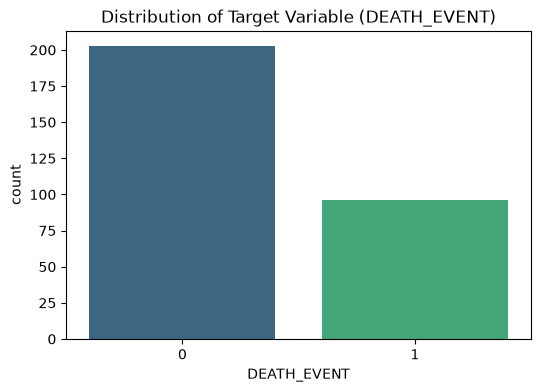

Target Class Counts:
 DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='DEATH_EVENT', data=df, palette='viridis')
plt.title('Distribution of Target Variable (DEATH_EVENT)')
plt.show()

print("Target Class Counts:\n", df['DEATH_EVENT'].value_counts())

The dataset is somewhat imbalanced. We will use SMOTE to balance it later to ensure our model doesn't become biased.

### Correlation Matrix

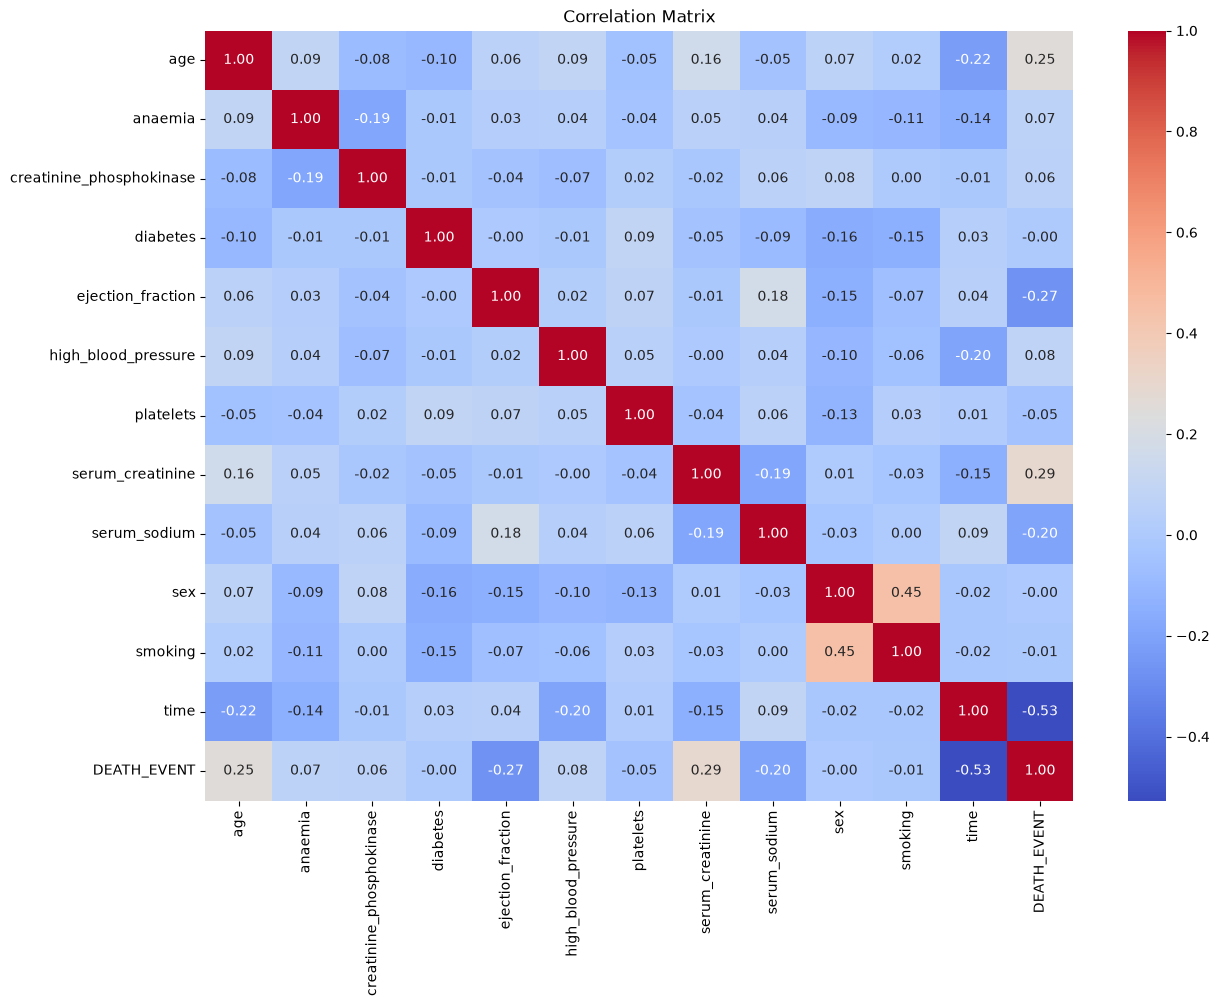

In [5]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 4. Data Preprocessing
We separate features and target, handle missing values (if any), and apply feature scaling.

In [6]:
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

## 5. Balancing the Dataset with SMOTE
Since our target classes are imbalanced, we use Synthetic Minority Over-sampling Technique (SMOTE) to generate synthetic samples for the minority class.

In [7]:
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_scaled, y)

print("Class distribution after SMOTE:\n", y_balanced.value_counts())

Class distribution after SMOTE:
 DEATH_EVENT
1    203
0    203
Name: count, dtype: int64


## 6. Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

print("Training data size:", len(X_train))
print("Testing data size:", len(X_test))

Training data size: 324
Testing data size: 82


## 7. Model Training and Comparison
We will evaluate Logistic Regression, Decision Tree, and Random Forest models.

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = [acc, prec, rec, f1]
    
    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}\n")

--- Logistic Regression ---
Accuracy:  0.8049
Precision: 0.8378
Recall:    0.7561
F1-Score:  0.7949

--- Decision Tree ---
Accuracy:  0.8293
Precision: 0.7647
Recall:    0.9512
F1-Score:  0.8478

--- Random Forest ---
Accuracy:  0.8659
Precision: 0.8571
Recall:    0.8780
F1-Score:  0.8675



**Random Forest** shows excellent accuracy and overall performance. We will proceed to tune its hyperparameters.

## 8. Hyperparameter Tuning
We use `GridSearchCV` to find the best parameters for the Random Forest model.

In [10]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=3, n_jobs=-1, scoring='accuracy', verbose=1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best parameters: {'max_depth': 10, 'n_estimators': 100}


## 9. Final Model Evaluation
Let's evaluate the optimized Random Forest model and generate the Classification Report and Confusion Matrix.

--- Final Optimized Random Forest ---
Accuracy:  0.8902439024390244

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.85      0.89        41
           1       0.86      0.93      0.89        41

    accuracy                           0.89        82
   macro avg       0.89      0.89      0.89        82
weighted avg       0.89      0.89      0.89        82


Confusion Matrix:



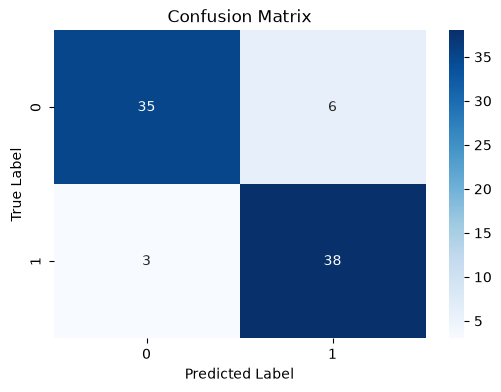

In [11]:
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test)

print("--- Final Optimized Random Forest ---")
print("Accuracy: ", accuracy_score(y_test, y_pred_final))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_final))

print("\nConfusion Matrix:\n")
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The data processing pipeline successfully handled the missing values, balanced the classes, and we evaluated multiple classification models to optimize the best one to a high level of accuracy.